In [17]:
import matplotlib.pyplot as plt
import mplscience
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import scipy

DATA_DIR="/path/to/kpspatial/data/dir"


In [2]:
def read_gmt(file):

    gene_sets = {}
    with open(file, 'r') as f:

        lines = f.readlines()
        for line in lines:
            line = line.strip()
            name = line.split("\t")[0]
            genes = line.split("\t")[2:]

            gene_sets[name] = genes

    return gene_sets

m_hallmark = read_gmt("/path/to/msgidb/mouse/signatures/mh.all.v2023.2.Mm.symbols.gmt")
tgfb_genes = m_hallmark['HALLMARK_TGF_BETA_SIGNALING']
hypoxia_genes = m_hallmark['HALLMARK_HYPOXIA']
myogenesis_genes = m_hallmark['HALLMARK_MYOGENESIS']

signatures = {'Collagen': {'Acta2', 'Col1a1', 'Col1a2', 'Col3a1', 'Col5a1', 'Col12a1'},
              'HALLMARK_TGF_BETA_SIGNALING':  m_hallmark['HALLMARK_TGF_BETA_SIGNALING'],
              'HALLMARK_HYPOXIA': m_hallmark['HALLMARK_HYPOXIA'],
              'HALLMARK_MYOGENESIS': m_hallmark['HALLMARK_MYOGENESIS']
}

other_genes = ["Epcam", "Cdh1", "Krt18", "Krt8", 'Krt7', 'Vim', 'Hmga2', 'Fn1', 'Twist1', 'Twist2', 'Snai1', 'Zeb1', 'Zeb2', 'Axl', 'Cdh2', 'Cd44', 'Myc']


In [9]:
KPTRACER_DATA = "/path/to/kptracer_2022/data/"
kp_tracer_raw = sc.read_10x_mtx(f'{KPTRACER_DATA}/expression/raw//NT/mm10')
kp_tracer_meta = pd.read_csv(f"{KPTRACER_DATA}/KPTracer_meta.csv", sep=',', index_col = 0)

kp_tracer_raw.raw = kp_tracer_raw.copy()

kp_tracer_raw

AnnData object with n_obs × n_vars = 59092 × 27998
    var: 'gene_ids'

In [10]:
kp_tracer = kp_tracer_raw.raw.to_adata()

overlapping = np.intersect1d(kp_tracer_meta.index.values, kp_tracer.obs_names)
kp_tracer = kp_tracer[overlapping,:]
kp_tracer.obs = kp_tracer_meta.loc[kp_tracer.obs_names]

kp_tracer.obs['is_met'] = kp_tracer.obs.apply(lambda x: type(x.Tumor) == str and x.Tumor.split("_")[-1][0] != 'T' and 'Normal' not in x.Tumor , axis=1).astype(str)
kp_tracer.obs['tumor_id'] = kp_tracer.obs['Tumor']
kp_tracer.obs['tumor_boundary'] = False
kp_tracer.obs['library_id'] = kp_tracer.obs['Tumor']

In [11]:
kp_tracer_mets = kp_tracer[(kp_tracer.obs['is_met'] == 'True') | (kp_tracer.obs['Tumor'].isin(['3724_NT_T1', '3513_NT_T1']))]


In [12]:
sc.pp.normalize_total(kp_tracer_mets, target_sum=1e6)
sc.pp.log1p(kp_tracer_mets)

sc.pp.scale(kp_tracer_mets)

for signature in signatures:
    genes = signatures[signature]
    print(signature)
    
    sc.tl.score_genes(kp_tracer_mets, genes, ctrl_size=50, n_bins=25, score_name=signature, use_raw=False)

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Collagen
HALLMARK_TGF_BETA_SIGNALING
HALLMARK_HYPOXIA
       'Large1'],
      dtype='object')
HALLMARK_MYOGENESIS


## Extended Data Figure 10a

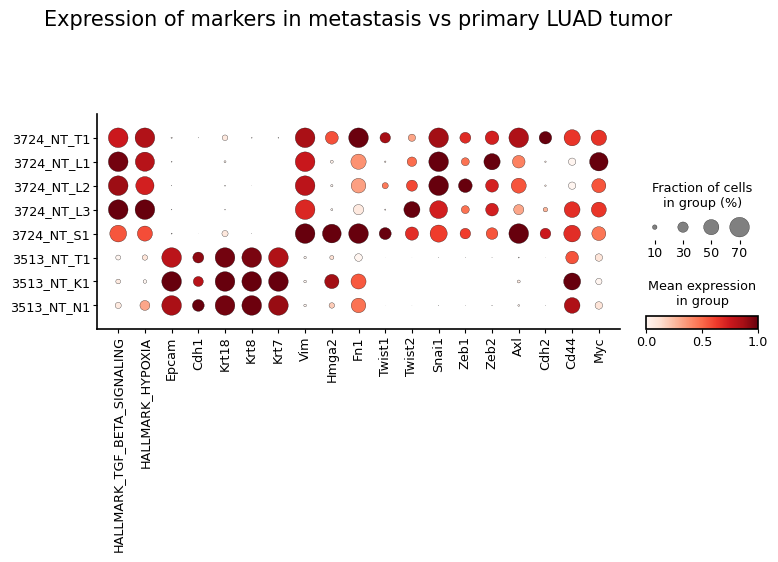

In [13]:
with mplscience.style_context():
    sc.pl.dotplot(
        kp_tracer_mets,
        var_names = ['HALLMARK_TGF_BETA_SIGNALING', 'HALLMARK_HYPOXIA'] + other_genes,
        groupby='library_id',
        dot_max=0.7,
        use_raw=False,
        standard_scale='var',
        show=False,
        swap_axes=False,
        categories_order=['3724_NT_T1', '3724_NT_L1', '3724_NT_L2', '3724_NT_L3', '3724_NT_S1', '3513_NT_T1', '3513_NT_K1', '3513_NT_N1'],
        title=f"Expression of markers in metastasis vs primary LUAD tumor"
    )
    plt.show()

In [14]:
import anndata

# Read in expression data from Chuang et al, Nature Medicine 2018 (PMID 28191885)
chuang_expression = pd.read_csv("/path/to/data/chuang_expression.txt", sep='\t')

sample_type = list(chuang_expression.iloc[0,8:].values)
sample_name = list(chuang_expression.columns[8:])
header = ['Ensembl', 'gene_symbol'] + sample_name 

chuang_expression = chuang_expression.iloc[3:,]
chuang_expression.drop(columns=chuang_expression.columns[[2,3,4,5,6,7]], inplace=True)
chuang_expression.columns = header

chuang_expression = chuang_expression[~chuang_expression.iloc[:,1].isna()]
chuang_expression.fillna(value=0, inplace=True)

meta = pd.DataFrame(sample_type, index=sample_name, columns=['annotation'])
var = chuang_expression.iloc[:,:2]
var.index = var['gene_symbol']

other_genes_cap = ['EPCAM', 'CHD1', 'KRT18', 'KRT8', 'KRT7', 'VIM', 'HMGA2', 'FN1', 'TWIST1', 'TWIST2', 'SNAI1', 'ZEB1', 'ZEB2', 'AXL', 'CDH2', 'CD44', 'MYC']

chuang_adata = anndata.AnnData(X = chuang_expression.iloc[:,2:].T.values.astype(float), obs=meta, var=var)
chuang_adata.var_names_make_unique()

/tmp/ipykernel_525612/4032945826.py:4: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62) have mixed types. Specify dtype option on import or set low_memory=False.
  chuang_expression = pd.read_csv("/orcd/data/ki/001/lab/jones/mgjones/stanford_mac_backup/kptc_spatial/data/chuang_expression.txt", sep='\t')
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


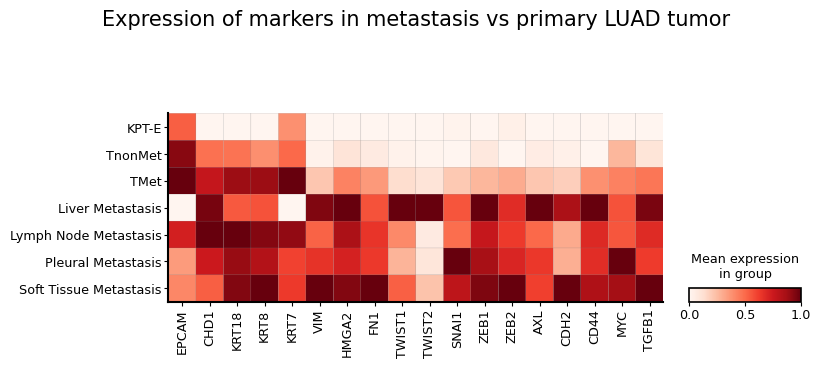

In [15]:
chuang_adata_to_plot = chuang_adata[~chuang_adata.obs['annotation'].isin(['Normal Lung', 'KT', 'Pleural DTCs'])].copy()

with mplscience.style_context():
    sc.pl.matrixplot(
        chuang_adata_to_plot,
        var_names = other_genes_cap + ['TGFB1'],
        groupby='annotation',
        # groupby='MetStatus',
        # use_raw=False,
        standard_scale='var',
        show=False,
        swap_axes=False,
        cmap='Reds',
        categories_order = ['KPT-E', 'TnonMet', 'TMet', 'Liver Metastasis', 'Lymph Node Metastasis', 'Pleural Metastasis', 'Soft Tissue Metastasis'],
        title=f"Expression of markers in metastasis vs primary LUAD tumor"
    )
    plt.show()

## Extended Data Figure 10c

In [18]:
MET_SAMPLES=["C36_09", "C36_10", "C44_06", "C44_08"]

adata_to_combine = []
for i, sample_name in zip(range(len(MET_SAMPLES)), MET_SAMPLES):
    print(sample_name)

    
    adata = sc.read_h5ad(f"{DATA_DIR}/slideseq/expression/{sample_name}_adata.h5ad")
    adata.var_names = adata.var_names.astype(str)
    adata.var_names_make_unique()

    adata.obs['library_id'] = sample_name
    adata.obs['is_tumor'] = (adata.obs['tumor_id'] != 'non-tumor') 
    
    adata.obs_names = [f'{sample_name}.{cellbc}' for cellbc in adata.obs_names]

    adata_to_combine.append(adata)

adata_combined = sc.concat(adata_to_combine)

adata_combined

C36_09


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


C36_10


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


C44_06
C44_08


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 50933 × 55421
    obs: 'TS-UMI', 'N_intBC', 'TS-ReadCount', 'N_unique_alleles', 'PercentUncut', 'targetsite', 'tumor', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'tumor_id', 'tumor_boundary', 'library_id', 'is_tumor'
    obsm: 'spatial'

In [19]:
# normalize
sc.pp.normalize_total(adata_combined, target_sum=1e6)
sc.pp.log1p(adata_combined)

sc.pp.scale(adata_combined)

/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Collagen


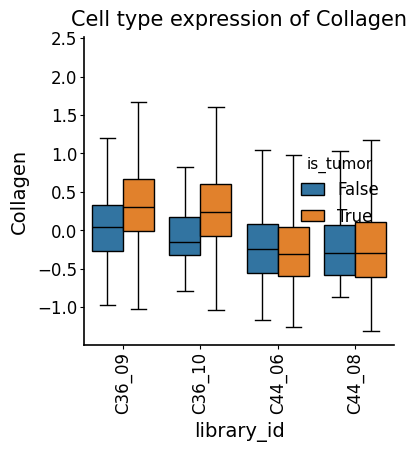

HALLMARK_TGF_BETA_SIGNALING


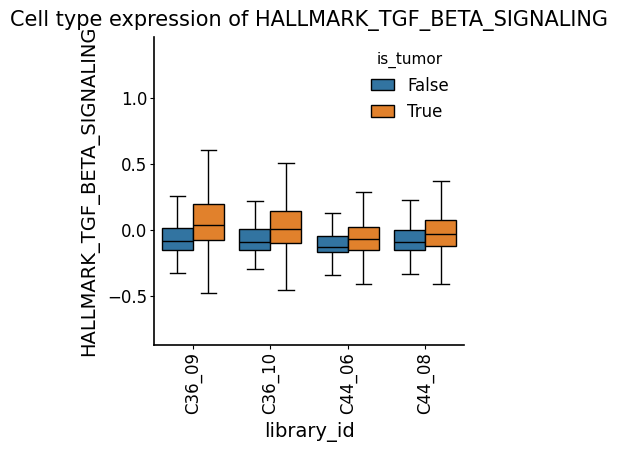

HALLMARK_HYPOXIA


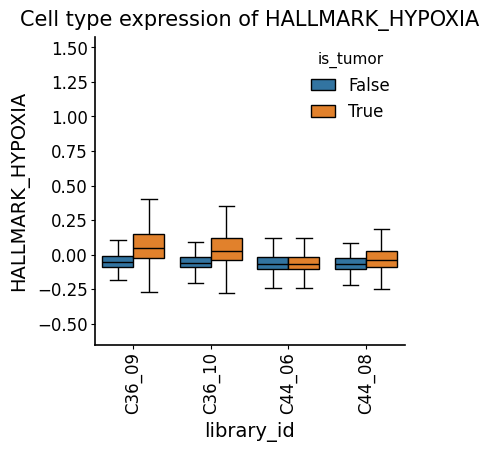

HALLMARK_MYOGENESIS


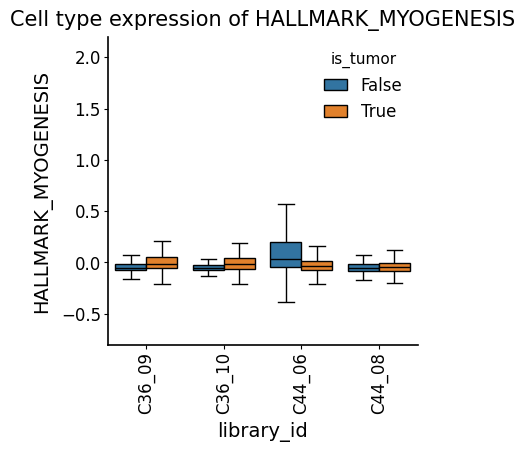

In [20]:
for signature in signatures:
    genes = signatures[signature]
    print(signature)
    
    sc.tl.score_genes(adata_combined, genes, ctrl_size=50, n_bins=25, score_name=signature, use_raw=False)
    
    with mplscience.style_context():
    
        sns.boxplot(data=adata_combined.obs, x='library_id', y=signature, hue='is_tumor', fliersize=0, linecolor='black')
        plt.xticks(rotation=90)
        plt.title(f'Cell type expression of {signature}')
        plt.show()


In [21]:
for signature in signatures:

    for tumor in adata_combined.obs['library_id'].unique():

        adata_sub = adata_combined[adata_combined.obs['library_id'] == tumor]
        
        tumor_area = adata_sub.obs.loc[adata_sub.obs['is_tumor'] == True, signature].values
        non_tumor_area = adata_sub.obs.loc[adata_sub.obs['is_tumor'] == False, signature].values
        
        pval = scipy.stats.ranksums(tumor_area, non_tumor_area, alternative='greater')[1]
    
        print(f'{tumor}, {signature} Pvalue: {round(pval, 3)}')

C36_09, Collagen Pvalue: 0.0
C36_10, Collagen Pvalue: 0.0
C44_06, Collagen Pvalue: 1.0
C44_08, Collagen Pvalue: 0.591
C36_09, HALLMARK_TGF_BETA_SIGNALING Pvalue: 0.0
C36_10, HALLMARK_TGF_BETA_SIGNALING Pvalue: 0.0
C44_06, HALLMARK_TGF_BETA_SIGNALING Pvalue: 0.0
C44_08, HALLMARK_TGF_BETA_SIGNALING Pvalue: 0.0
C36_09, HALLMARK_HYPOXIA Pvalue: 0.0
C36_10, HALLMARK_HYPOXIA Pvalue: 0.0
C44_06, HALLMARK_HYPOXIA Pvalue: 0.051
C44_08, HALLMARK_HYPOXIA Pvalue: 0.0
C36_09, HALLMARK_MYOGENESIS Pvalue: 0.0
C36_10, HALLMARK_MYOGENESIS Pvalue: 0.0
C44_06, HALLMARK_MYOGENESIS Pvalue: 1.0
C44_08, HALLMARK_MYOGENESIS Pvalue: 0.0
